# Conexão com Google Drive

O Google Drive foi integrado ao ambiente do Google Colab para permitir o acesso ao conjunto de dados.

A conexão foi realizada em modo somente leitura (readonly=True), garantindo a integridade dos arquivos durante o treinamento.

Em seguida, foi definido o caminho base do dataset (data_path), facilitando o acesso às imagens e aos arquivos de anotação utilizados pelo modelo YOLO.

In [1]:
from google.colab import drive
import os

drive.mount('/content/drive', readonly=True)
data_path = '/content/drive/MyDrive/fase_6'
data_cnn = '/content/drive/MyDrive/fase_6_entrega_2'

Mounted at /content/drive


# Instalação da biblioteca YOLO

A biblioteca Ultralytics foi instalada no ambiente Google Colab utilizando o gerenciador de pacotes pip. Essa biblioteca fornece a implementação do modelo YOLO, permitindo a realização de tarefas de detecção de objetos com suporte à aceleração por GPU.

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 10.5 MB/s eta 0:00:00


# Importação da biblioteca YOLO

A biblioteca Ultralytics foi importada no ambiente para disponibilizar o modelo YOLO, permitindo a execução das etapas de treinamento, validação e inferência do modelo de detecção de objetos.

In [ ]:
from ultralytics import YOLO
from IPython.display import Image, display
import glob

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# Carregamento do modelo YOLO

O modelo YOLOv8 pré-treinado foi utilizado como baseline. Ele foi treinado originalmente no dataset COCO, contendo classes genéricas, sem adaptação para os objetos específicos do presente projeto.

In [ ]:
model = YOLO("yolov8n.pt")

# Inferência nas imagens de teste.

As imagens de teste da Entrega 1 foram utilizadas para avaliar o desempenho do modelo YOLO pré-treinado em um cenário não adaptado.

In [ ]:
results = model.predict(
    source="/content/drive/MyDrive/Fase_6/images/test",
    save=True,
    conf=0.25
)


image 1/8 /content/drive/MyDrive/Fase_6/images/test/Apontador_33.jpg: 640x480 (no detections), 420.1ms
image 2/8 /content/drive/MyDrive/Fase_6/images/test/Apontador_34.jpg: 640x480 (no detections), 240.5ms
image 3/8 /content/drive/MyDrive/Fase_6/images/test/Apontador_35.jpg: 640x480 (no detections), 240.1ms
image 4/8 /content/drive/MyDrive/Fase_6/images/test/Apontador_36.jpg: 640x480 (no detections), 148.8ms
image 5/8 /content/drive/MyDrive/Fase_6/images/test/Mouse_33.jpg: 640x480 2 dining tables, 1 cell phone, 158.7ms
image 6/8 /content/drive/MyDrive/Fase_6/images/test/Mouse_34.jpg: 640x480 1 surfboard, 154.9ms
image 7/8 /content/drive/MyDrive/Fase_6/images/test/Mouse_35.jpg: 640x480 1 surfboard, 165.2ms
image 8/8 /content/drive/MyDrive/Fase_6/images/test/Mouse_36.jpg: 640x480 1 surfboard, 145.9ms
Speed: 6.7ms preprocess, 209.3ms inference, 5.4ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/predict


# Visualização dos resultados

As imagens processadas foram exibidas com bounding boxes e classes previstas pelo modelo, permitindo análise qualitativa dos resultados.

In [ ]:
images = glob.glob('/content/runs/detect/predict/*.jpg')

for img in images[:8]:
    display(Image(filename=img, width=350))

Output hidden; open in https://colab.research.google.com to view.

# Interpretação técnica

O YOLO pré-treinado foi capaz de realizar detecções, porém todas baseadas em classes do dataset COCO, não relacionadas aos objetos presentes no problema (mouse e apontador).

Isso resultou em baixa aderência ao cenário proposto, com ausência de detecções corretas para a classe “apontador” e classificações incorretas para a classe “mouse”.

# Conclusão

O modelo YOLO tradicional apresentou limitações significativas ao ser aplicado diretamente ao dataset personalizado. Como não foi treinado para as classes específicas do projeto, não conseguiu identificar corretamente os objetos, reforçando a necessidade de treinamento customizado para problemas específicos de visão computacional.

# CNN

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
import os

# Carregamento do dataset

Para o treinamento da CNN, as imagens foram organizadas em diretórios separados por classe, onde cada pasta representa um rótulo distinto (mouse e apontador).

O carregamento foi realizado utilizando a função image_dataset_from_directory, que permite a leitura automática das imagens e a atribuição dos rótulos com base na estrutura de pastas.

In [23]:
img_size = (128, 128)
batch_size = 8

train_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/Fase_6_entrega_2/train",
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/Fase_6_entrega_2/val",
    image_size=img_size,
    batch_size=batch_size
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/Fase_6_entrega_2/test",
    image_size=(128,128),
    batch_size=8,
    shuffle=False
)

test_ds = test_ds.map(lambda x, y: (x/255.0, y))

Found 64 files belonging to 2 classes.
Found 8 files belonging to 2 classes.
Found 6 files belonging to 2 classes.


# Normalização

As imagens foram normalizadas para o intervalo entre 0 e 1, com o objetivo de melhorar a estabilidade do treinamento e facilitar a convergência do modelo.

In [24]:
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

# Arquitetura da CNN

Foi implementada uma rede neural convolucional (CNN) do zero, composta por camadas convolucionais responsáveis pela extração de características, seguidas por camadas de pooling para redução de dimensionalidade.

Ao final, camadas densas foram utilizadas para realizar a classificação das imagens em duas classes, utilizando a função de ativação softmax.

In [25]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(2, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Compilação

O modelo foi compilado utilizando o otimizador Adam e a função de perda sparse_categorical_crossentropy, adequada para problemas de classificação com múltiplas classes representadas por inteiros

In [26]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Treinamento CNN

O modelo foi treinado por 10 épocas, considerando o tamanho reduzido do dataset disponível.

Em cenários com poucos dados, um número elevado de épocas pode levar ao overfitting, onde o modelo passa a memorizar os dados de treinamento sem generalizar para novas imagens.

Dessa forma, optou-se por um número moderado de épocas, suficiente para permitir o aprendizado dos padrões básicos sem comprometer a capacidade de generalização.

Além disso, o número reduzido de épocas contribui para limitar o ajuste excessivo do modelo aos dados de treino.

In [8]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.6250 - loss: 1.2973 - val_accuracy: 0.5000 - val_loss: 0.7204
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.5000 - loss: 0.7135 - val_accuracy: 0.5000 - val_loss: 0.6906
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 947ms/step - accuracy: 0.4062 - loss: 0.6936 - val_accuracy: 0.5000 - val_loss: 0.6866
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 988ms/step - accuracy: 0.5156 - loss: 0.6801 - val_accuracy: 0.5000 - val_loss: 0.6801
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 999ms/step - accuracy: 0.5938 - loss: 0.7073 - val_accuracy: 0.8750 - val_loss: 0.6732
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 934ms/step - accuracy: 0.7969 - loss: 0.6557 - val_accuracy: 1.0000 - val_loss: 0.5774
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 883ms/step - accuracy: 0.8906 - loss: 0.4991 - val_accuracy: 1.0000 - val_loss: 0.2151
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 994ms/step - accuracy: 0.9219 - loss: 0.2501 - val_accuracy: 1.0000 - val_loss: 0.

# Avaliação da CNN

O modelo CNN apresentou evolução significativa ao longo das épocas, com aumento da acurácia de treinamento e redução da função de perda.

Na etapa de validação, o modelo atingiu acurácia de 100%, porém esse resultado deve ser analisado com cautela, uma vez que o conjunto de validação é reduzido (apenas 8 imagens).

Dessa forma, existe a possibilidade de overfitting, onde o modelo se ajusta excessivamente aos dados disponíveis, não garantindo necessariamente boa generalização para novos dados.

In [27]:
loss, acc = model.evaluate(test_ds)
print("Acurácia no teste:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.5000 - loss: 0.7050
Acurácia no teste: 0.5


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step


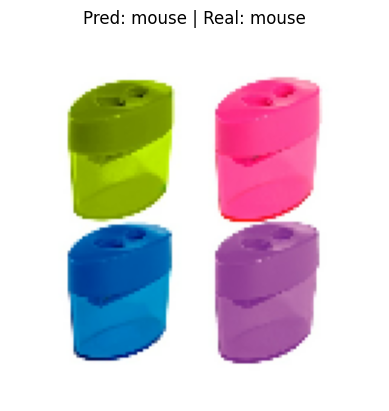

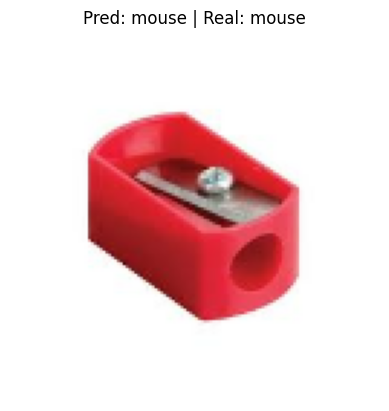

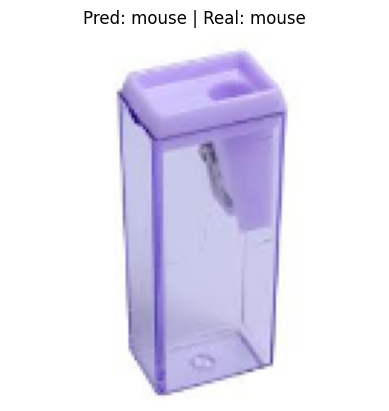

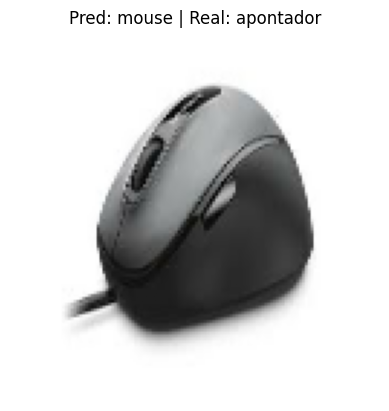

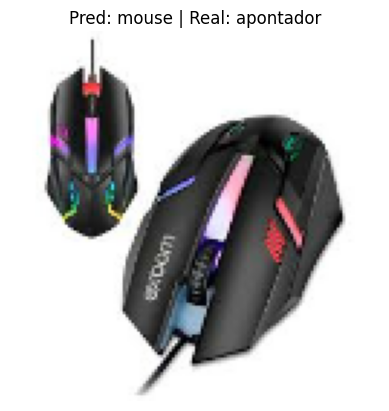

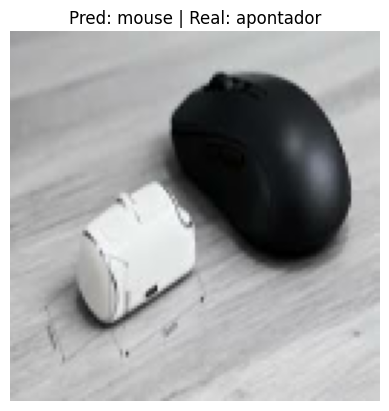

In [28]:
import matplotlib.pyplot as plt

class_names = ["mouse", "apontador"]

for images, labels in test_ds.take(1):
    predictions = model.predict(images)

    for i in range(len(images)):
        plt.imshow(images[i].numpy())
        pred_class = class_names[np.argmax(predictions[i])]
        true_class = class_names[labels[i]]

        plt.title(f"Pred: {pred_class} | Real: {true_class}")
        plt.axis("off")
        plt.show()

# Avaliação no conjunto de teste

O modelo CNN apresentou acurácia de 50% no conjunto de teste, indicando baixo desempenho em dados não vistos durante o treinamento.

Esse resultado evidencia que o modelo não conseguiu generalizar adequadamente para dados não vistos, apresentando comportamento equivalente a um classificador aleatório.

A diferença entre os resultados de validação e teste reforça a ocorrência de overfitting, possivelmente causada pelo tamanho reduzido do dataset e pela ausência de aprendizado prévio.

Em contraste, o modelo YOLO customizado apresentou melhor desempenho em imagens reais, devido ao uso de pesos pré-treinados e maior robustez na detecção de objetos.

# Conclusão Geral dos Modelos de Visão Computacional

## Visão geral do experimento

Neste projeto, foram avaliadas três abordagens distintas de visão computacional aplicadas à classificação e detecção de dois objetos (*mouse* e *apontador*), utilizando um dataset reduzido de aproximadamente 80 imagens, dividido em treino, validação e teste.

As abordagens analisadas foram:

- YOLO customizado (com fine-tuning)  
- YOLO pré-treinado (tradicional)  
- CNN treinada do zero  

---

## YOLO Customizado

O modelo YOLO customizado apresentou o melhor desempenho entre todas as abordagens testadas.

Durante o treinamento com 30 épocas, foram observados resultados elevados, com mAP50 próximo de 0.995 e mAP50-95 em torno de 0.77, além de precisão próxima de 0.98 e recall de 1.0. Esses resultados indicam que o modelo conseguiu identificar corretamente os objetos com alta confiabilidade.

Esse desempenho está diretamente relacionado ao uso de transferência de aprendizado. O modelo já possui conhecimento prévio adquirido em grandes bases de dados, o que permite que ele se adapte rapidamente a novos cenários, mesmo com um conjunto de dados reduzido.

Além disso, o modelo demonstrou boa capacidade de generalização, apresentando bons resultados também em imagens externas ao dataset original.

---

## YOLO Tradicional (Pré-treinado)

O modelo YOLO pré-treinado, sem qualquer ajuste, não apresentou desempenho satisfatório.

Ao ser aplicado nas imagens do projeto, o modelo não conseguiu identificar corretamente os objetos (*mouse* e *apontador*), realizando classificações incorretas como "surfboard" e "dining table", ou até mesmo não detectando nenhum objeto.

Esse comportamento ocorre porque o modelo foi originalmente treinado em um conjunto de dados genérico (COCO dataset), que não contempla necessariamente os objetos no mesmo contexto utilizado neste projeto.

Esse resultado evidencia que modelos pré-treinados, sem adaptação, não são eficazes para problemas específicos.

---

## CNN Treinada do Zero

A CNN treinada do zero apresentou resultados aparentemente bons durante o treinamento, mas falhou na generalização.

Durante o treino, a acurácia evoluiu até aproximadamente 93%, enquanto a validação atingiu 100%. No entanto, ao avaliar o modelo no conjunto de teste, a acurácia caiu para 50%, o que equivale a um desempenho próximo ao aleatório.

Esse comportamento caracteriza um claro caso de overfitting.

---

## Análise das limitações da CNN

O baixo desempenho da CNN pode ser explicado por alguns fatores principais.

Primeiramente, o dataset utilizado é pequeno, com cerca de 64 imagens de treino. Essa quantidade é insuficiente para que uma rede neural treinada do zero consiga aprender padrões robustos e generalizáveis.

Além disso, o conjunto de validação contém apenas 8 imagens, o que facilita a obtenção de resultados artificialmente altos, sem necessariamente refletir a capacidade real do modelo.

Outro ponto crítico é a ausência de transferência de aprendizado. Diferente do YOLO, a CNN precisa aprender todas as características do zero, o que exige uma quantidade muito maior de dados.

Por fim, os resultados indicam claramente overfitting, onde o modelo aprende muito bem os dados de treino, mas falha ao lidar com dados novos.

---

## Comparação geral

Os resultados obtidos ao longo do projeto demonstram diferenças claras entre as abordagens.

O YOLO customizado se destacou por sua alta precisão e excelente capacidade de generalização, mesmo com um dataset limitado.

O YOLO tradicional, por outro lado, mostrou que modelos genéricos não são eficazes sem adaptação ao problema específico.

Já a CNN treinada do zero apresentou forte dependência do dataset e baixa capacidade de generalização, evidenciando a necessidade de maior volume de dados ou uso de técnicas mais avançadas.

---

## Conclusão final

Com base nos experimentos realizados, o modelo YOLO customizado se mostrou a melhor solução para o problema proposto.

A utilização de transferência de aprendizado foi determinante para alcançar bons resultados, permitindo que o modelo aprendesse de forma eficiente mesmo com poucos dados.

Por outro lado, a CNN treinada do zero evidenciou limitações importantes, principalmente relacionadas à necessidade de grandes volumes de dados e à suscetibilidade ao overfitting.

Já o YOLO tradicional demonstrou que modelos pré-treinados, sem ajuste, não são adequados para aplicações específicas.

---

## Considerações finais

Em cenários reais, a escolha da abordagem deve considerar fatores como disponibilidade de dados, tempo de desenvolvimento e necessidade de generalização.

Neste contexto, técnicas baseadas em transferência de aprendizado se mostram mais eficientes e práticas, especialmente em projetos com limitações de dados, como o apresentado neste trabalho.